# OCR PLAT NOMOR

Notebook ini membaca crop plat dari `04_inference.ipynb`, menjalankan PaddleOCR, membersihkan teks, dan menyimpan hasil OCR ke CSV.


# Import Library


In [13]:
from pathlib import Path
import re

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from paddleocr import PaddleOCR


# Inisialisasi OCR


In [14]:
ocr = PaddleOCR(
    use_angle_cls=True,
    lang="en"
)

[2026/06/27 13:07:35] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/home/betenk/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/home/betenk/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num

# Folder Crop


In [15]:
CROP_DIR = Path("../outputs/images")

crop_files = sorted(CROP_DIR.glob("*"))

print(f"Jumlah crop : {len(crop_files)}")

Jumlah crop : 13


# show crop


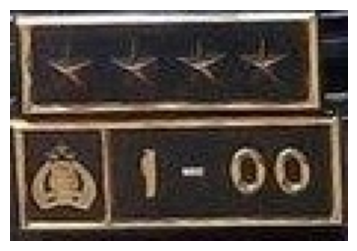

In [16]:
sample = crop_files[0]

img = cv2.imread(str(sample))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,3))
plt.imshow(img)
plt.axis("off")
plt.show()

# OCR


In [17]:
result = ocr.ocr(str(sample))

print(result)

[2026/06/27 13:07:36] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.008054733276367188
[2026/06/27 13:07:36] ppocr DEBUG: cls num  : 0, elapsed : 0
[2026/06/27 13:07:36] ppocr DEBUG: rec_res num  : 0, elapsed : 1.1920928955078125e-06
[None]


# ambil hasil


In [18]:
texts = []

if result is not None and result[0] is not None:
    for line in result[0]:
        text = line[1][0]
        conf = line[1][1]
        texts.append((text, conf))

print(texts)

[]


# Preprocessing


(np.float64(-0.5), np.float64(341.5), np.float64(233.5), np.float64(-0.5))

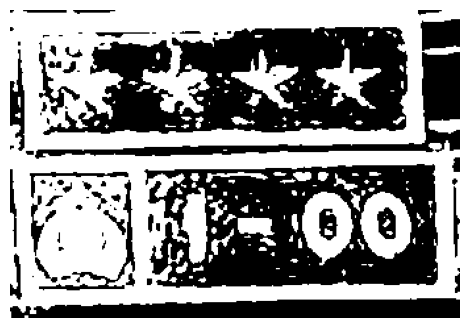

In [19]:
img = cv2.imread(str(sample))

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

gray = cv2.resize(gray, None, fx=3, fy=3)

gray = cv2.GaussianBlur(gray, (3,3), 0)

gray = cv2.equalizeHist(gray)

_, thresh = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.figure(figsize=(10,4))
plt.imshow(thresh, cmap="gray")
plt.axis("off")

# Ocr After Preprocessing

In [20]:
temp = "../outputs/temp.jpg"

cv2.imwrite(temp, thresh)

result = ocr.ocr(temp)

result

[2026/06/27 13:07:36] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.03361225128173828
[2026/06/27 13:07:36] ppocr DEBUG: cls num  : 0, elapsed : 0
[2026/06/27 13:07:36] ppocr DEBUG: rec_res num  : 0, elapsed : 1.1920928955078125e-06


[None]

# OCR SEMUA GAMBAR

In [21]:
records = []

for file in crop_files:

    result = ocr.ocr(str(file))

    text = ""

    confidence = 0

    if result[0]:

        text = " ".join([r[1][0] for r in result[0]])

        confidence = max([r[1][1] for r in result[0]])

    records.append({
        "image":file.name,
        "plate":text,
        "confidence":confidence
    })

[2026/06/27 13:07:36] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.005453348159790039
[2026/06/27 13:07:36] ppocr DEBUG: cls num  : 0, elapsed : 0
[2026/06/27 13:07:36] ppocr DEBUG: rec_res num  : 0, elapsed : 4.76837158203125e-07
[2026/06/27 13:07:36] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.011992454528808594
[2026/06/27 13:07:36] ppocr DEBUG: cls num  : 0, elapsed : 0
[2026/06/27 13:07:36] ppocr DEBUG: rec_res num  : 0, elapsed : 4.76837158203125e-07
[2026/06/27 13:07:36] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.014162540435791016
[2026/06/27 13:07:36] ppocr DEBUG: cls num  : 0, elapsed : 0
[2026/06/27 13:07:36] ppocr DEBUG: rec_res num  : 0, elapsed : 7.152557373046875e-07
[2026/06/27 13:07:36] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.01751542091369629
[2026/06/27 13:07:36] ppocr DEBUG: cls num  : 0, elapsed : 0
[2026/06/27 13:07:36] ppocr DEBUG: rec_res num  : 0, elapsed : 7.152557373046875e-07
[2026/06/27 13:07:36] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.003999471664428711

# DATA FRAME

In [22]:
df = pd.DataFrame(records)

df

,image,plate,confidence
0,plate_1.jpg,,0
1,plate_10.jpg,,0
2,plate_11.jpg,,0
3,plate_12.jpg,,0
4,plate_13.jpg,,0
5,plate_2.jpg,,0
6,plate_3.jpg,,0
7,plate_4.jpg,,0
8,plate_5.jpg,,0
9,plate_6.jpg,,0


# Simpan CSV

In [23]:
save_path = "../outputs/ocr_result.csv"

df.to_csv(save_path,index=False)

print(save_path)

../outputs/ocr_result.csv
